# ASCON First-Round DPA/CPA Clean Trace Collection

This notebook recollects the **paper-style ASCON first-round fixed-key random-nonce DPA/CPA dataset** with improved capture settings.

Main changes from the clipped dataset:
- lower gain
- longer sample window
- gain test before full collection
- clipping check before collecting 30,000 / 50,000 traces
- firmware flashing before collection

Default final setting:
- `scope.adc.samples = 12000`
- `N_FULL = 30000`
- test gains `[25, 28, 30, 32, 35]`


In [1]:

import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import chipwhisperer as cw

print("Imports OK")


C:\Users\thetp\anaconda3\envs\cw\lib\site-packages\chipwhisperer\capture\trace\TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


Imports OK


## 1. Paths and experiment settings

In [2]:

ASCON_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

FW_PATH = ASCON_ROOT / "01_Firmware" / "first_round_dpa" / "simpleserial-ascon-firstround-dpa" / "simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex"

DATA_BASE = ASCON_ROOT / "03_Data" / "first_round_dpa"
DATA_BASE.mkdir(parents=True, exist_ok=True)

FIXED_KEY_HEX = "00112233445566778899aabbccddeeff"
FIXED_KEY = bytes.fromhex(FIXED_KEY_HEX)

# Recommended: 30000 first. Use 50000 only if time/storage allows.
N_FULL = 50000

# Improved settings
ADC_SAMPLES = 12000
ADC_OFFSET = 0

# Gain values to test before full collection
TEST_GAINS = [25, 28, 30, 32, 35]
N_GAIN_TEST = 30
N_SMOKE = 100

# Update this after gain test
CHOSEN_GAIN = 28

RUN_NAME = f"ascon_firstround_fixedkey_randomnonce_{N_FULL}_gain{CHOSEN_GAIN}_samples{ADC_SAMPLES}_" + datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = DATA_BASE / RUN_NAME

print("Firmware path:", FW_PATH)
print("Firmware exists:", FW_PATH.exists())
print("Data base:", DATA_BASE)
print("Planned run folder:", RUN_DIR)
print("Fixed key:", FIXED_KEY_HEX)

assert FW_PATH.exists(), f"Firmware not found: {FW_PATH}"


Firmware path: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
Firmware exists: True
Data base: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa
Planned run folder: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064721
Fixed key: 00112233445566778899aabbccddeeff


## 2. Connect to ChipWhisperer and flash firmware

In [3]:

try:
    scope.dis()
except Exception:
    pass

try:
    target.dis()
except Exception:
    pass

scope = cw.scope()
target = cw.target(scope)

print("Connected to ChipWhisperer scope and target")


Connected to ChipWhisperer scope and target


In [4]:

scope.gain.db = CHOSEN_GAIN
scope.adc.samples = ADC_SAMPLES
scope.adc.offset = ADC_OFFSET
scope.adc.basic_mode = "rising_edge"

scope.clock.clkgen_freq = 7.37e6
scope.clock.adc_src = "clkgen_x4"

scope.trigger.triggers = "tio4"

scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "clkgen"

scope.adc.timeout = 2

print("Scope settings:")
print("  gain:", scope.gain.db)
print("  samples:", scope.adc.samples)
print("  offset:", scope.adc.offset)
print("  clkgen_freq:", scope.clock.clkgen_freq)
print("  adc_src:", scope.clock.adc_src)
print("  trigger:", scope.trigger.triggers)


Scope settings:
  gain: 28.05859375
  samples: 12000
  offset: 0
  clkgen_freq: 7384615.384615385
  adc_src: clkgen_x4
  trigger: tio4


In [5]:

print("Flashing firmware:")
print(FW_PATH)

cw.program_target(scope, cw.programmers.XMEGAProgrammer, str(FW_PATH))

time.sleep(0.5)
target.flush()

print("Firmware flashed successfully")


Flashing firmware:
C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Firmware flashed successfully


## 3. SimpleSerial sanity test

The new firmware uses:
- `k` = load fixed 16-byte key
- `n` = load random 16-byte nonce
- `p` = run first-round capture with **empty payload**
- `r` = 1-byte checksum response


capture_ret: False
response: db
trace length: 12000
trace min/max: -0.5 0.2978515625
trigger_count: 10880


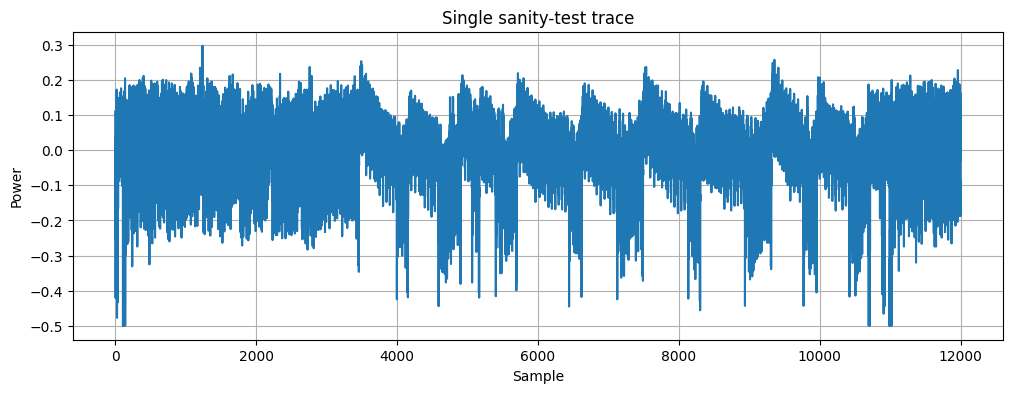

In [6]:

nonce = os.urandom(16)

target.flush()

target.simpleserial_write('k', bytearray(FIXED_KEY))
time.sleep(0.05)

target.simpleserial_write('n', bytearray(nonce))
time.sleep(0.05)

scope.arm()
target.simpleserial_write('p', bytearray([]))

ret = scope.capture()
resp = target.simpleserial_read('r', 1, timeout=1000)
trace = scope.get_last_trace()

print("capture_ret:", ret)
print("response:", resp.hex() if resp else None)
print("trace length:", len(trace))
print("trace min/max:", np.min(trace), np.max(trace))

try:
    print("trigger_count:", scope.adc.trig_count)
except Exception as e:
    print("trigger_count not available:", e)

plt.figure(figsize=(12, 4))
plt.plot(trace)
plt.title("Single sanity-test trace")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()


## 4. Gain test

Run this before full collection. Choose the highest gain where clipping is still close to zero.

Recommended:
- good: clipping `< 0.01`
- better: clipping `< 0.001`
- bad: clipping `> 0.05`



Testing gain: 25

Testing gain: 28

Testing gain: 30

Testing gain: 32

Testing gain: 35


,gain,trace_shape,min,max,clipping_fraction,capture_ret_unique,empty_responses,unique_nonces,trigger_count_unique
0,25,"(30, 12000)",-0.5,0.211914,0.000525,[False],0,30,[10880]
1,28,"(30, 12000)",-0.5,0.316406,0.001578,[False],0,30,[10880]
2,30,"(30, 12000)",-0.5,0.384766,0.004347,[False],0,30,[10880]
3,32,"(30, 12000)",-0.5,0.471680,0.007989,[False],0,30,[10880]
4,35,"(30, 12000)",-0.5,0.499023,0.037389,[False],0,30,[10880]


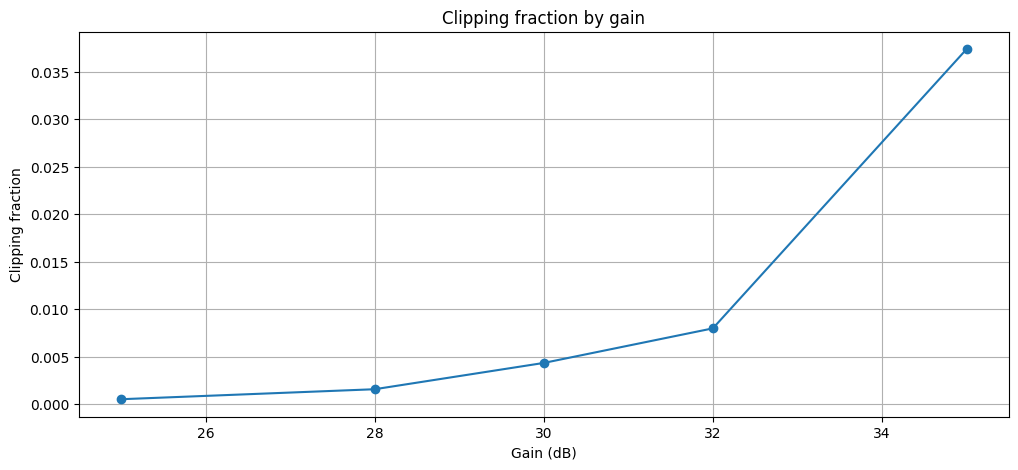

In [7]:

target.flush()
target.simpleserial_write('k', bytearray(FIXED_KEY))
time.sleep(0.05)

gain_rows = {}
scope.adc.samples = ADC_SAMPLES
scope.adc.offset = ADC_OFFSET

gain_results = []

for gain in TEST_GAINS:
    scope.gain.db = gain
    time.sleep(0.05)

    test_traces = []
    capture_rets = []
    responses = []
    trigger_counts = []
    nonces = []

    print("\nTesting gain:", gain)

    for i in range(N_GAIN_TEST):
        nonce = os.urandom(16)
        nonces.append(nonce.hex())

        target.simpleserial_write('n', bytearray(nonce))
        time.sleep(0.002)

        scope.arm()
        target.simpleserial_write('p', bytearray([]))

        ret = scope.capture()
        resp = target.simpleserial_read('r', 1, timeout=1000)
        tr = scope.get_last_trace()

        test_traces.append(tr)
        capture_rets.append(ret)
        responses.append(resp.hex() if resp else "")

        try:
            trigger_counts.append(scope.adc.trig_count)
        except Exception:
            trigger_counts.append(None)

    test_traces = np.array(test_traces, dtype=np.float32)
    clipping = ((test_traces <= -0.49) | (test_traces >= 0.49)).mean()

    gain_results.append({
        "gain": gain,
        "trace_shape": str(test_traces.shape),
        "min": float(test_traces.min()),
        "max": float(test_traces.max()),
        "clipping_fraction": float(clipping),
        "capture_ret_unique": str(sorted(set(capture_rets))),
        "empty_responses": int(sum(r == "" for r in responses)),
        "unique_nonces": int(len(set(nonces))),
        "trigger_count_unique": str(sorted(set(trigger_counts)))
    })

gain_df = pd.DataFrame(gain_results)
display(gain_df)

plt.figure(figsize=(12, 5))
plt.plot(gain_df["gain"], gain_df["clipping_fraction"], marker="o")
plt.title("Clipping fraction by gain")
plt.xlabel("Gain (dB)")
plt.ylabel("Clipping fraction")
plt.grid(True)
plt.show()


## 5. Choose gain

After checking the gain table above, update `CHOSEN_GAIN`.

Example:
```python
CHOSEN_GAIN = 30
```


In [8]:

CHOSEN_GAIN = 28

scope.gain.db = CHOSEN_GAIN
scope.adc.samples = ADC_SAMPLES
scope.adc.offset = ADC_OFFSET

RUN_NAME = f"ascon_firstround_fixedkey_randomnonce_{N_FULL}_gain{CHOSEN_GAIN}_samples{ADC_SAMPLES}_" + datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = DATA_BASE / RUN_NAME

print("Chosen gain:", CHOSEN_GAIN)
print("Final run folder will be:", RUN_DIR)


Chosen gain: 28
Final run folder will be: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747


## 6. Smoke test with chosen gain

In [9]:

def collect_traces(num_traces, progress_every=1000):
    traces = []
    metadata_rows = []

    target.flush()
    target.simpleserial_write('k', bytearray(FIXED_KEY))
    time.sleep(0.05)

    for i in range(num_traces):
        nonce = os.urandom(16)

        target.simpleserial_write('n', bytearray(nonce))
        time.sleep(0.002)

        scope.arm()
        target.simpleserial_write('p', bytearray([]))

        ret = scope.capture()
        resp = target.simpleserial_read('r', 1, timeout=1000)

        tr = scope.get_last_trace()
        traces.append(tr)

        try:
            trig_count = scope.adc.trig_count
        except Exception:
            trig_count = None

        metadata_rows.append({
            "trace_index": i,
            "key_hex": FIXED_KEY_HEX,
            "nonce_hex": nonce.hex(),
            "response_hex": resp.hex() if resp else "",
            "capture_ret": ret,
            "trigger_count": trig_count
        })

        if progress_every and ((i + 1) % progress_every == 0):
            print(f"Collected {i + 1}/{num_traces}")

    traces = np.array(traces, dtype=np.float32)
    metadata_df = pd.DataFrame(metadata_rows)
    return traces, metadata_df


def qc_report(traces, metadata_df, title="QC"):
    sat = ((traces <= -0.49) | (traces >= 0.49))

    print("=" * 70)
    print(title)
    print("=" * 70)
    print("traces shape:", traces.shape)
    print("metadata shape:", metadata_df.shape)
    print("trace min:", traces.min())
    print("trace max:", traces.max())
    print("overall clipping fraction:", sat.mean())
    print("median clipping per trace:", np.median(sat.mean(axis=1)))
    print("max clipping per trace:", sat.mean(axis=1).max())

    print("\ncapture_ret counts:")
    print(metadata_df["capture_ret"].value_counts(dropna=False))

    print("\nempty responses:", (metadata_df["response_hex"] == "").sum())
    print("unique nonces:", metadata_df["nonce_hex"].nunique(), "/", len(metadata_df))

    print("\ntrigger_count counts:")
    print(metadata_df["trigger_count"].value_counts(dropna=False).head(10))

    plt.figure(figsize=(12, 4))
    for i in range(min(10, len(traces))):
        plt.plot(traces[i], alpha=0.6)
    plt.title(title + " - first traces")
    plt.xlabel("Sample")
    plt.ylabel("Power")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(traces.mean(axis=0))
    plt.title(title + " - mean trace")
    plt.xlabel("Sample")
    plt.ylabel("Mean power")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(traces.std(axis=0))
    plt.title(title + " - STD trace")
    plt.xlabel("Sample")
    plt.ylabel("STD")
    plt.grid(True)
    plt.show()


Re-flashing firmware before smoke test...
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Smoke test: gain=28, samples=12000
traces shape: (100, 12000)
metadata shape: (100, 6)
trace min: -0.5
trace max: 0.31347656
overall clipping fraction: 0.0016075
median clipping per trace: 0.0015833333333333333
max clipping per trace: 0.0018333333333333333

capture_ret counts:
capture_ret
False    100
Name: count, dtype: int64

empty responses: 0
unique nonces: 100 / 100

trigger_count counts:
trigger_count
10880    100
Name: count, dtype: int64


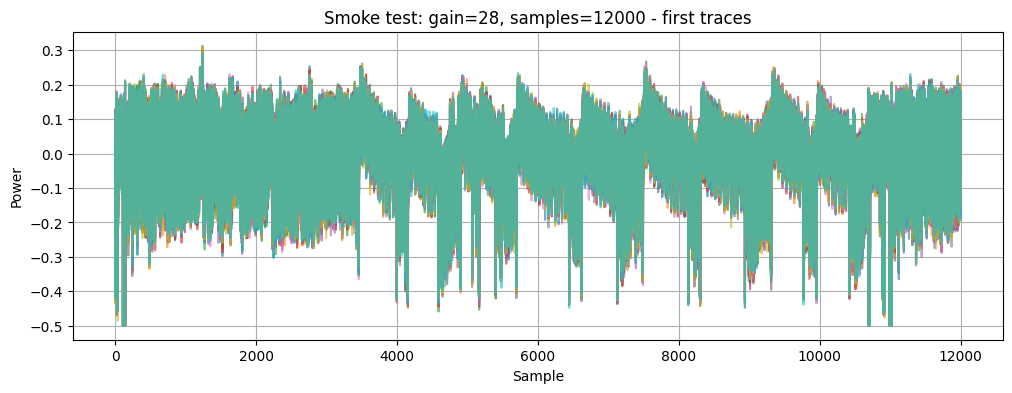

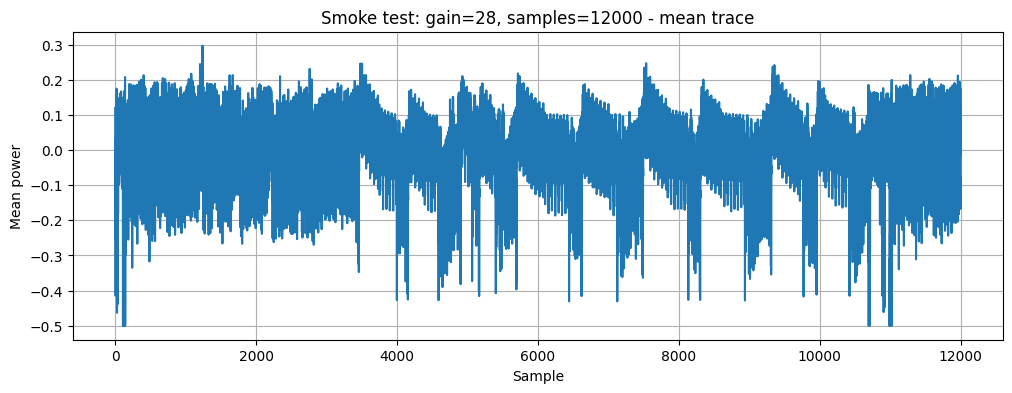

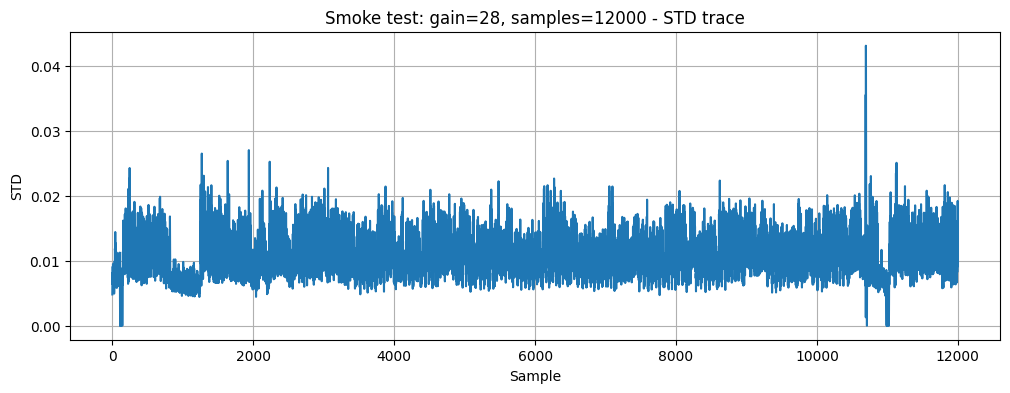

In [10]:

print("Re-flashing firmware before smoke test...")
cw.program_target(scope, cw.programmers.XMEGAProgrammer, str(FW_PATH))
time.sleep(0.5)
target.flush()

scope.gain.db = CHOSEN_GAIN
scope.adc.samples = ADC_SAMPLES
scope.adc.offset = ADC_OFFSET

smoke_traces, smoke_meta = collect_traces(N_SMOKE, progress_every=0)
qc_report(smoke_traces, smoke_meta, title=f"Smoke test: gain={CHOSEN_GAIN}, samples={ADC_SAMPLES}")


## 7. Save smoke test

In [11]:

SMOKE_DIR = DATA_BASE / ("smoketest_clean_gain{}_samples{}_".format(CHOSEN_GAIN, ADC_SAMPLES) + datetime.now().strftime("%Y%m%d_%H%M%S"))
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

np.save(SMOKE_DIR / "traces.npy", smoke_traces)
smoke_meta.to_csv(SMOKE_DIR / "metadata.csv", index=False)

smoke_config = {
    "experiment": "ASCON first-round DPA clean smoke test",
    "firmware_path": str(FW_PATH),
    "firmware_file": FW_PATH.name,
    "data_base": str(DATA_BASE),
    "fixed_key_hex": FIXED_KEY_HEX,
    "nonce_mode": "random 16-byte nonce per trace",
    "num_traces": int(N_SMOKE),
    "p_command_payload": "empty bytearray",
    "scope_gain_db": float(scope.gain.db),
    "scope_adc_samples": int(scope.adc.samples),
    "scope_adc_offset": int(scope.adc.offset),
    "scope_adc_basic_mode": str(scope.adc.basic_mode),
    "scope_clkgen_freq": float(scope.clock.clkgen_freq),
    "scope_adc_src": str(scope.clock.adc_src),
    "trigger": str(scope.trigger.triggers),
    "created_at": datetime.now().isoformat(),
    "notes": "Clean recollection smoke test. Fixed key + random nonce. Trigger around first ASCON initialization ROUND(s, 0xf0). No byte loop."
}

with open(SMOKE_DIR / "config.json", "w") as f:
    json.dump(smoke_config, f, indent=4)

print("Smoke test saved to:", SMOKE_DIR)


Smoke test saved to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\smoketest_clean_gain28_samples12000_20260616_064806


## 8. Full collection

Only run this if the smoke test passes.

Checklist:
- `capture_ret` is all `False`
- unique nonces = number of traces
- empty responses = 0
- trigger count stable
- clipping fraction is close to zero, ideally `< 0.001` or at least `< 0.01`


Re-flashing firmware before full collection...
XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 12105 bytes
Starting full collection
N_FULL: 50000
RUN_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747
gain: 28.05859375
samples: 12000
Collected 1000/50000
Collected 2000/50000
Collected 3000/50000
Collected 4000/50000
Collected 5000/50000
Collected 6000/50000
Collected 7000/50000
Collected 8000/50000
Collected 9000/50000
Collected 10000/50000
Collected 11000/50000
Collected 12000/50000
Collected 13000/50000
Collected 14000/50000
Collected 15000/50000
Collected 16000/50000
Collected 17000/50000
Collected 18000/50000
Collected 19000/50000
Collected 20000/50000
Collected 21000/50000
Collected 22000/50000
Collected 23000/50000
Collected 24000/50000
Collected 25000/50000
Collected 26000/50000
Collected 27000/50000
Collected 28000/50000
Collected 29000/50000
Collected 30000/50000
C

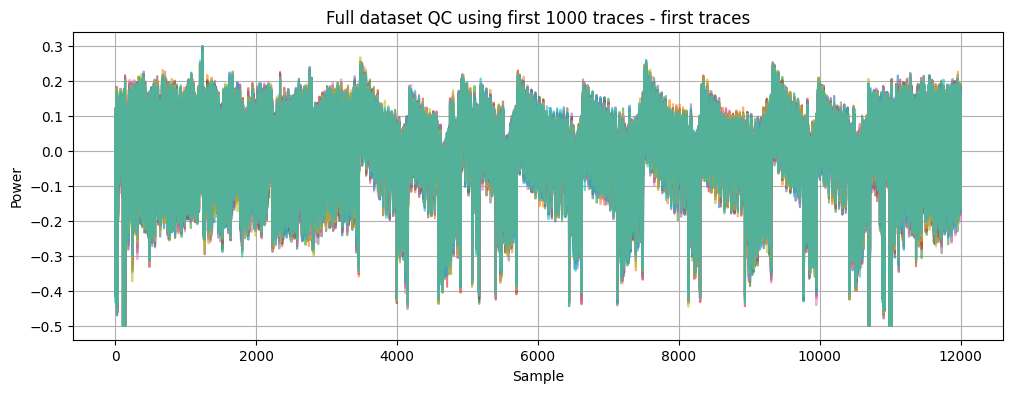

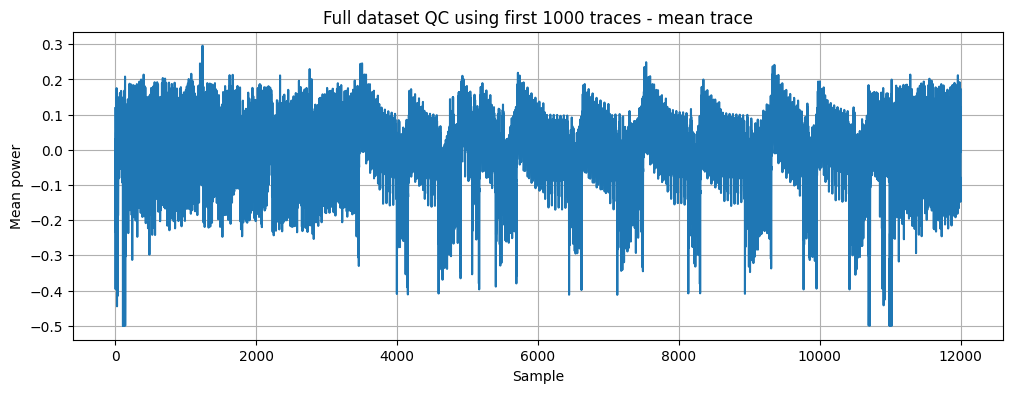

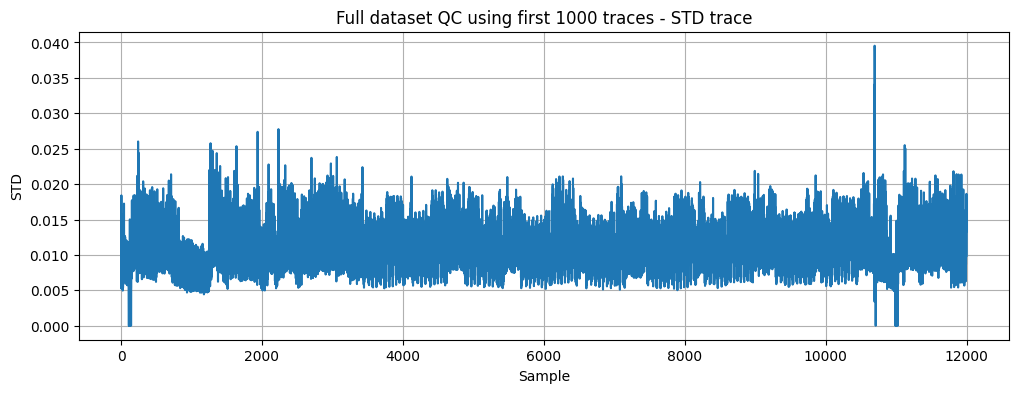

Saved full dataset to: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747


In [12]:

RUN_FULL_COLLECTION = True

if not RUN_FULL_COLLECTION:
    print("Full collection is disabled.")
    print("Set RUN_FULL_COLLECTION = True in this cell after smoke test passes.")
else:
    RUN_DIR.mkdir(parents=True, exist_ok=True)

    print("Re-flashing firmware before full collection...")
    cw.program_target(scope, cw.programmers.XMEGAProgrammer, str(FW_PATH))
    time.sleep(0.5)
    target.flush()

    scope.gain.db = CHOSEN_GAIN
    scope.adc.samples = ADC_SAMPLES
    scope.adc.offset = ADC_OFFSET

    print("Starting full collection")
    print("N_FULL:", N_FULL)
    print("RUN_DIR:", RUN_DIR)
    print("gain:", scope.gain.db)
    print("samples:", scope.adc.samples)

    full_traces, full_meta = collect_traces(N_FULL, progress_every=1000)

    print("Full collection done.")
    qc_report(full_traces[:min(1000, len(full_traces))], full_meta.iloc[:min(1000, len(full_meta))], title="Full dataset QC using first 1000 traces")

    np.save(RUN_DIR / "traces.npy", full_traces)
    full_meta.to_csv(RUN_DIR / "metadata.csv", index=False)

    full_config = {
        "experiment": "ASCON first-round DPA fixed-key random-nonce clean trace collection",
        "firmware_path": str(FW_PATH),
        "firmware_file": FW_PATH.name,
        "data_base": str(DATA_BASE),
        "fixed_key_hex": FIXED_KEY_HEX,
        "nonce_mode": "random 16-byte nonce per trace",
        "num_traces": int(N_FULL),
        "p_command_payload": "empty bytearray",
        "scope_gain_db": float(scope.gain.db),
        "scope_adc_samples": int(scope.adc.samples),
        "scope_adc_offset": int(scope.adc.offset),
        "scope_adc_basic_mode": str(scope.adc.basic_mode),
        "scope_clkgen_freq": float(scope.clock.clkgen_freq),
        "scope_adc_src": str(scope.clock.adc_src),
        "trigger": str(scope.trigger.triggers),
        "created_at": datetime.now().isoformat(),
        "notes": "Clean recollection. Fixed key + random nonce. Trigger is inside ascon_first_round_dpa_capture(), around first ASCON initialization ROUND(s, 0xf0). No byte loop."
    }

    with open(RUN_DIR / "config.json", "w") as f:
        json.dump(full_config, f, indent=4)

    print("Saved full dataset to:", RUN_DIR)


## 9. Reload saved full dataset and check QC

In [13]:

CHECK_SAVED_DATASET = False

if not CHECK_SAVED_DATASET:
    print("Saved dataset QC disabled.")
    print("Set CHECK_SAVED_DATASET = True after full collection.")
else:
    saved_traces = np.load(RUN_DIR / "traces.npy", mmap_mode="r")
    saved_meta = pd.read_csv(RUN_DIR / "metadata.csv")

    print("Saved traces shape:", saved_traces.shape)
    print("Saved metadata shape:", saved_meta.shape)

    sample = np.asarray(saved_traces[:1000], dtype=np.float32)
    qc_report(sample, saved_meta.iloc[:1000].copy(), title="Saved full dataset QC, first 1000 traces")


Saved dataset QC disabled.
Set CHECK_SAVED_DATASET = True after full collection.


traces shape: (50000, 12000)
metadata shape: (50000, 6)
sample min: -0.5
sample max: 0.32128906
overall clipping fraction: 0.0018289166666666666
median clipping per trace: 0.0018333333333333333
max clipping per trace: 0.0021666666666666666


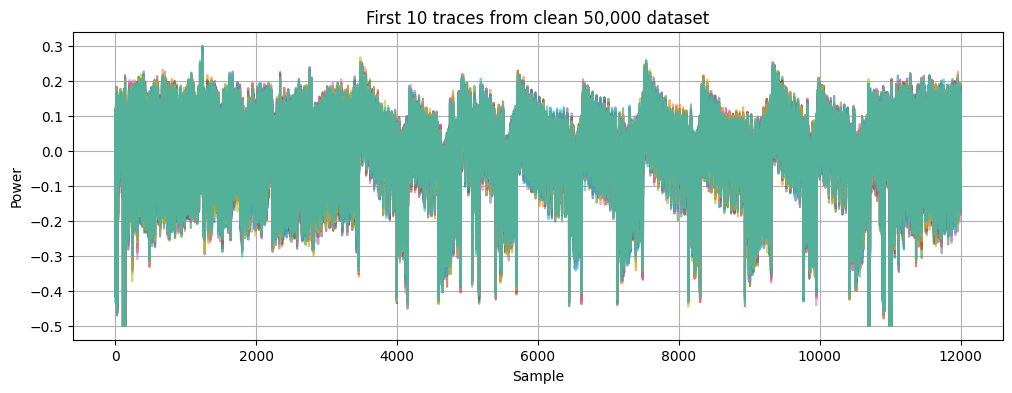

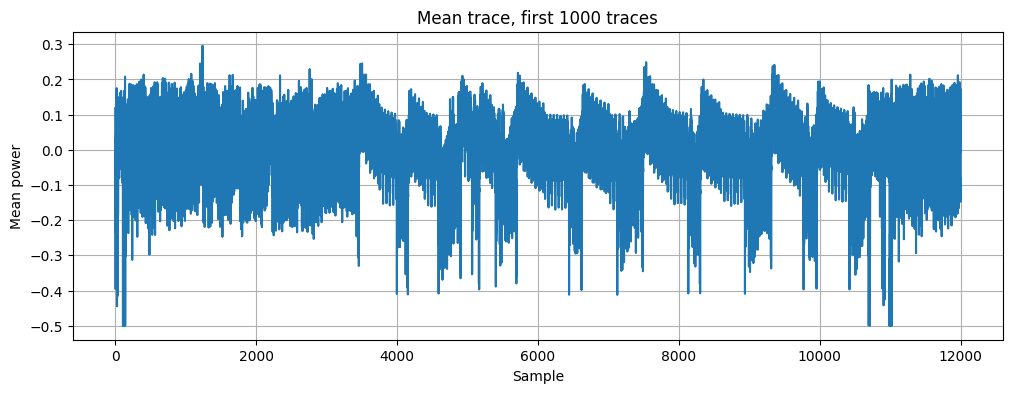

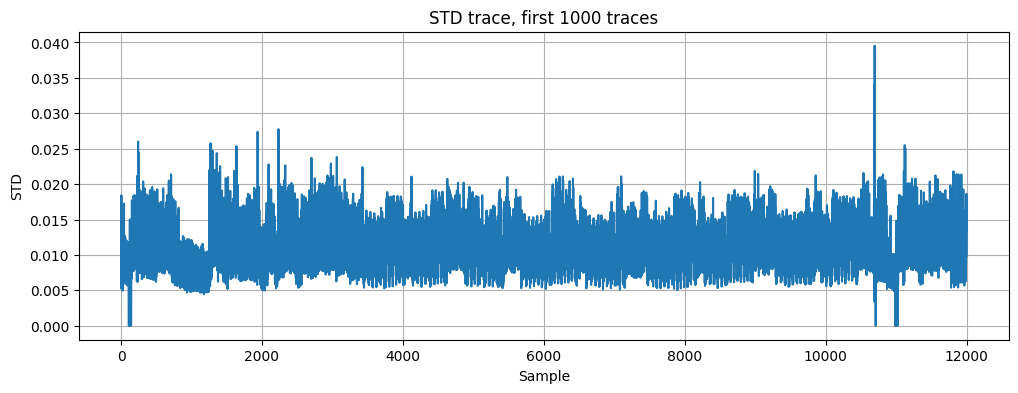

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

run_dir = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747")

# If your file is traces.npy:
trace_path = run_dir / "traces.npy"

# If your file is traces.npz, change this:
# trace_path = run_dir / "traces.npz"

metadata = pd.read_csv(run_dir / "metadata.csv")

if trace_path.suffix == ".npy":
    traces = np.load(trace_path, mmap_mode="r")
else:
    data = np.load(trace_path)
    print("NPZ keys:", data.files)
    traces = data[data.files[0]]

print("traces shape:", traces.shape)
print("metadata shape:", metadata.shape)

sample = np.asarray(traces[:1000], dtype=np.float32)

sat = ((sample <= -0.49) | (sample >= 0.49))

print("sample min:", sample.min())
print("sample max:", sample.max())
print("overall clipping fraction:", sat.mean())
print("median clipping per trace:", np.median(sat.mean(axis=1)))
print("max clipping per trace:", sat.mean(axis=1).max())

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.plot(sample[i], alpha=0.6)
plt.title("First 10 traces from clean 50,000 dataset")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample.mean(axis=0))
plt.title("Mean trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("Mean power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample.std(axis=0))
plt.title("STD trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("STD")
plt.grid(True)
plt.show()

## 10. Next step after collection

After this notebook finishes and the clean dataset passes QC:

1. Open `ASCON_FirstRound_x0_Bit_CPA_DPA_Test.ipynb`
2. Set `RUN_DIR` to the new clean dataset folder
3. Run x′0 CPA/DPA again
4. Compare with the old clipped dataset
5. Then proceed to x′1 CPA/DPA
